# Telco Customer Churn Prediction

This notebook predicts which telecom customers are likely to churn (cancel their subscription)  
using classical ML and gradient boosting models, with SHAP-based explainability.

**Pipeline Overview:**
1. Data Loading & Inspection
2. Preprocessing & Feature Engineering
3. Encoding & Scaling
4. Model Training (LR, RF, XGBoost, LightGBM)
5. Hyperparameter Tuning (XGBoost)
6. Evaluation: ROC-AUC, Classification Report, Confusion Matrix
7. Explainability with SHAP

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',40)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Data & Initial Inspection

In [2]:
df = pd.read_excel('F:\Telco_customer_churn.xlsx')

print(f'Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head(3)

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [ ]:
print(df.dtypes)
print(f'\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nChurn distribution:\n{df["Churn Label"].value_counts()}')

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

Missing values per column:
C

## 3. Drop Irrelevant Columns

We remove identifiers, geographic details, and target-leaking columns  
(`Churn Label`, `Churn Score`, `CLTV`, `Churn Reason`) that would not be  
available at the time of real prediction.

In [4]:
cols_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude',
    'Churn Label',   # text version of target — leakage
    'Churn Score',   # derived churn probability — leakage
    'CLTV',          # customer lifetime value — post-hoc metric, leakage
    'Churn Reason'   # reason only known after churn — leakage
]

df.drop(columns=cols_to_drop, inplace=True)
print(f'Remaining columns ({df.shape[1]}): {df.columns.tolist()}')

Remaining columns (20): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


## 4. Fix Data Types & Handle Missing Values

In [5]:
# 'Total Charges' can arrive as string due to spaces — coerce to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print(f'NaN count in Total Charges before drop: {df["Total Charges"].isna().sum()}')
df.dropna(inplace=True)
print(f'Dataset shape after drop: {df.shape}')

NaN count in Total Charges before drop: 11
Dataset shape after drop: (7032, 20)


## 5. Feature Engineering


In [6]:
# Tenure Group — captures non-linear loyalty effect
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 48, 100],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr']
)

# Value Score — proxy for customer worth (spend × time)
df['Value Score'] = df['Monthly Charges'] * df['Tenure Months']

# Total Services subscribed — engagement indicator
services = [
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]
df['Total Services'] = (df[services] == 'Yes').sum(axis=1)

# Average Monthly Spend — normalises total charges by tenure
# +1 avoids division by zero for customers with Tenure = 0
df['Avg Monthly Spend'] = df['Total Charges'] / (df['Tenure Months'] + 1)

# High Risk flag — month-to-month contract + very new customer
df['High Risk'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure Months'] < 12)
).astype(int)

print('Feature engineering complete.')
df[['Tenure Group', 'Value Score', 'Total Services', 'Avg Monthly Spend', 'High Risk']].head()

Feature engineering complete.


,Tenure Group,Value Score,Total Services,Avg Monthly Spend,High Risk
0,0-1yr,107.7,2,36.050000,1
1,0-1yr,141.4,0,50.550000,1
2,0-1yr,797.2,3,91.166667,1
3,2-4yr,2934.4,4,105.036207,0
4,4+yr,5081.3,4,100.726000,0


### 5a. EDA — Churn by Key Features

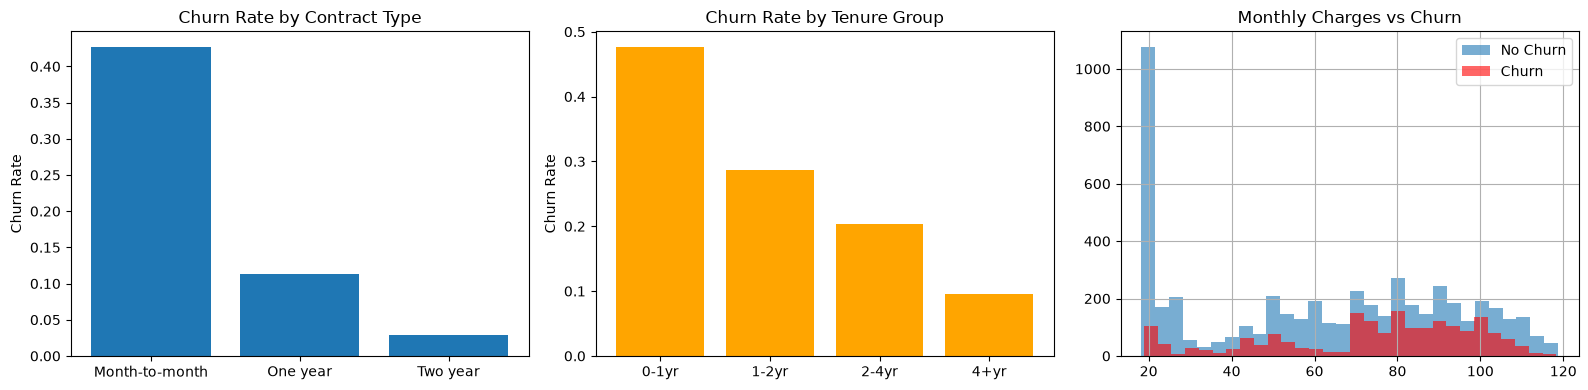

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn rate by Contract type
churn_contract = df.groupby('Contract')['Churn Value'].mean().reset_index()
axes[0].bar(churn_contract['Contract'], churn_contract['Churn Value'])
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')

# Churn rate by Tenure Group
churn_tenure = df.groupby('Tenure Group', observed=True)['Churn Value'].mean().reset_index()
axes[1].bar(churn_tenure['Tenure Group'].astype(str), churn_tenure['Churn Value'], color='orange')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_ylabel('Churn Rate')

# Monthly Charges distribution by Churn
df[df['Churn Value'] == 0]['Monthly Charges'].hist(ax=axes[2], alpha=0.6, label='No Churn', bins=30)
df[df['Churn Value'] == 1]['Monthly Charges'].hist(ax=axes[2], alpha=0.6, label='Churn', bins=30, color='red')
axes[2].set_title('Monthly Charges vs Churn')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Encoding

In [8]:
# Standardise ambiguous negative values to a clean 'No'
df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

# Binary label encoding for Yes/No columns
binary_cols = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Senior Citizen arrived as Yes/No string — map to int
df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categoricals (drop_first avoids multicollinearity)
df = pd.get_dummies(df, drop_first=True)

print(f'Final shape after encoding: {df.shape}')

Final shape after encoding: (7032, 31)


## 7. Train / Test Split

In [9]:
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# stratify=y preserves the churn/no-churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate  — Train: {y_train.mean():.2%}  Test: {y_test.mean():.2%}')

# Class imbalance weight for tree models
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train: (5625, 30), Test: (1407, 30)
Churn rate  — Train: 26.58%  Test: 26.58%
scale_pos_weight: 2.76


## 8. Model Training

We use **sklearn Pipelines** (improvement over original) so that  
the scaler is fit on training data only — preventing data leakage.

In [10]:
# --- Logistic Regression (with Pipeline + StandardScaler) ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
print(f'LR      ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}')

LR      ROC-AUC: 0.8431


In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # IMPROVEMENT: added class_weight
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
print(f'RF      ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}')

RF      ROC-AUC: 0.8337


In [12]:
# --- XGBoost with GridSearchCV ---
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# IMPROVEMENT: use StratifiedKFold explicitly for reliable AUC estimates on imbalanced data
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    xgb_base, param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

print(f'Best params: {grid_xgb.best_params_}')
print(f'XGBoost ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
XGBoost ROC-AUC: 0.8452


In [13]:
# --- LightGBM ---
lgbm = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
print(f'LightGBM ROC-AUC: {roc_auc_score(y_test, lgbm_prob):.4f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM ROC-AUC: 0.8327


## 9. Model Comparison

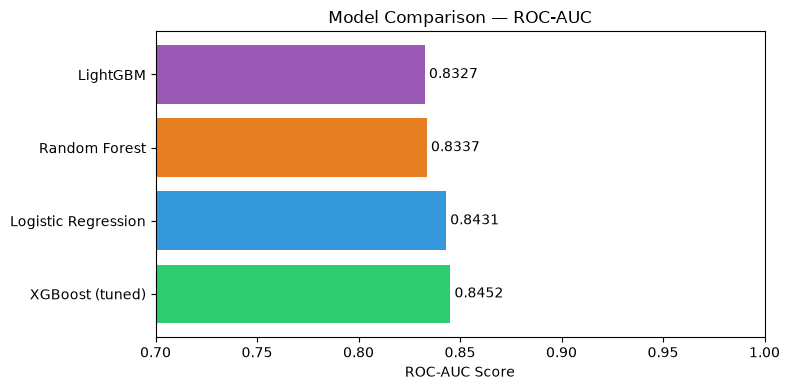

              Model  ROC-AUC
    XGBoost (tuned) 0.845249
Logistic Regression 0.843140
      Random Forest 0.833675
           LightGBM 0.832704


In [14]:
results = {
    'Logistic Regression': roc_auc_score(y_test, lr_prob),
    'Random Forest':       roc_auc_score(y_test, rf_prob),
    'XGBoost (tuned)':     roc_auc_score(y_test, xgb_prob),
    'LightGBM':            roc_auc_score(y_test, lgbm_prob)
}

results_df = pd.Series(results).sort_values(ascending=False).reset_index()
results_df.columns = ['Model', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(results_df['Model'], results_df['ROC-AUC'], color=['#2ecc71', '#3498db', '#e67e22', '#9b59b6'])
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('ROC-AUC Score')
ax.set_title('Model Comparison — ROC-AUC')
for bar, val in zip(bars, results_df['ROC-AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## 10. Detailed Evaluation on Best Model (XGBoost)

In [15]:
# Classification Report
best_preds_default = best_xgb.predict(X_test)
print('=== Classification Report (default 0.5 threshold) ===')
print(classification_report(y_test, best_preds_default, target_names=['No Churn', 'Churn']))

=== Classification Report (default 0.5 threshold) ===
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



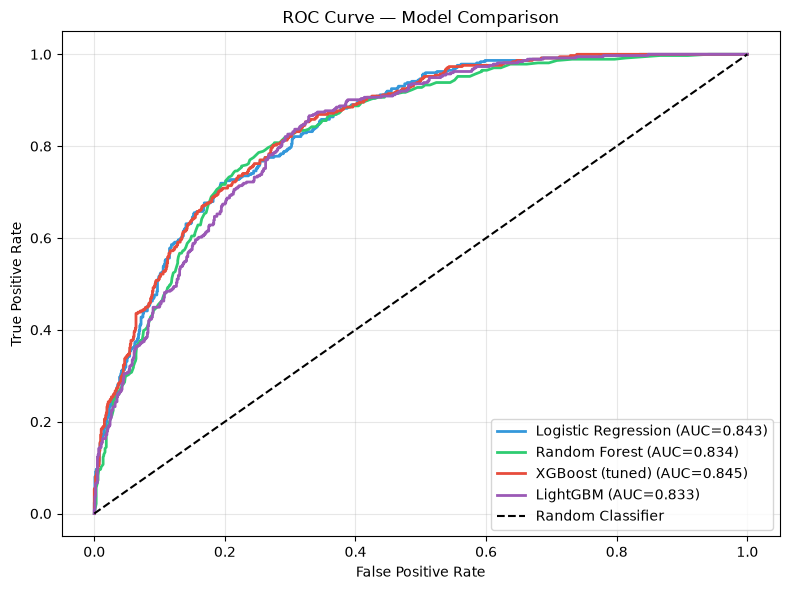

In [16]:
# ROC Curve — all models
model_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest':       rf_prob,
    'XGBoost (tuned)':     xgb_prob,
    'LightGBM':            lgbm_prob
}

plt.figure(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for (name, probs), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

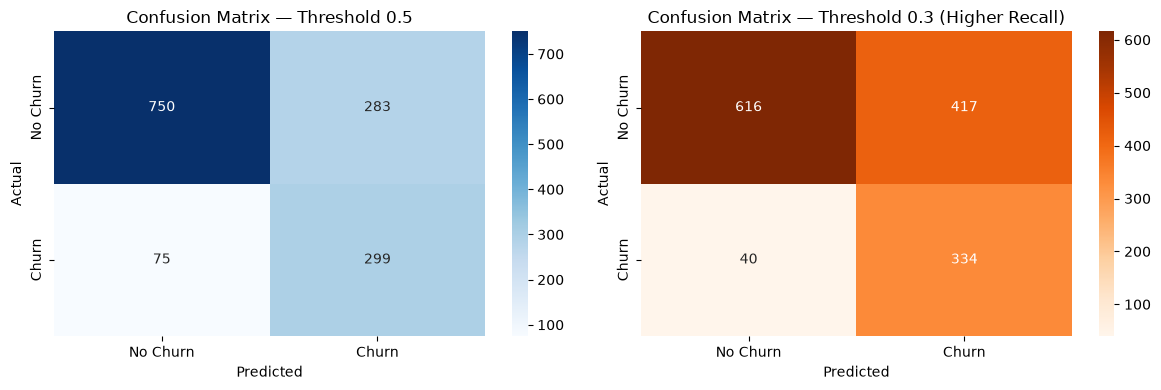

=== Report at threshold 0.3 ===
              precision    recall  f1-score   support

    No Churn       0.94      0.60      0.73      1033
       Churn       0.44      0.89      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.66      1407
weighted avg       0.81      0.68      0.69      1407



In [17]:
# Confusion Matrix at default threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm1 = confusion_matrix(y_test, best_preds_default)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix — Threshold 0.5')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Custom threshold 0.3 — prioritises catching churners (higher recall for churn class)
# Business rationale: retaining a customer is cheaper than acquiring a new one
custom_preds = (xgb_prob > 0.3).astype(int)
cm2 = confusion_matrix(y_test, custom_preds)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1], cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix — Threshold 0.3 (Higher Recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('=== Report at threshold 0.3 ===')
print(classification_report(y_test, custom_preds, target_names=['No Churn', 'Churn']))

## 11. SHAP Explainability

SHAP (SHapley Additive exPlanations) shows *which features* drive each prediction  
— a must-have for any production churn model in business settings.

--- Global Feature Importance (mean |SHAP|) ---


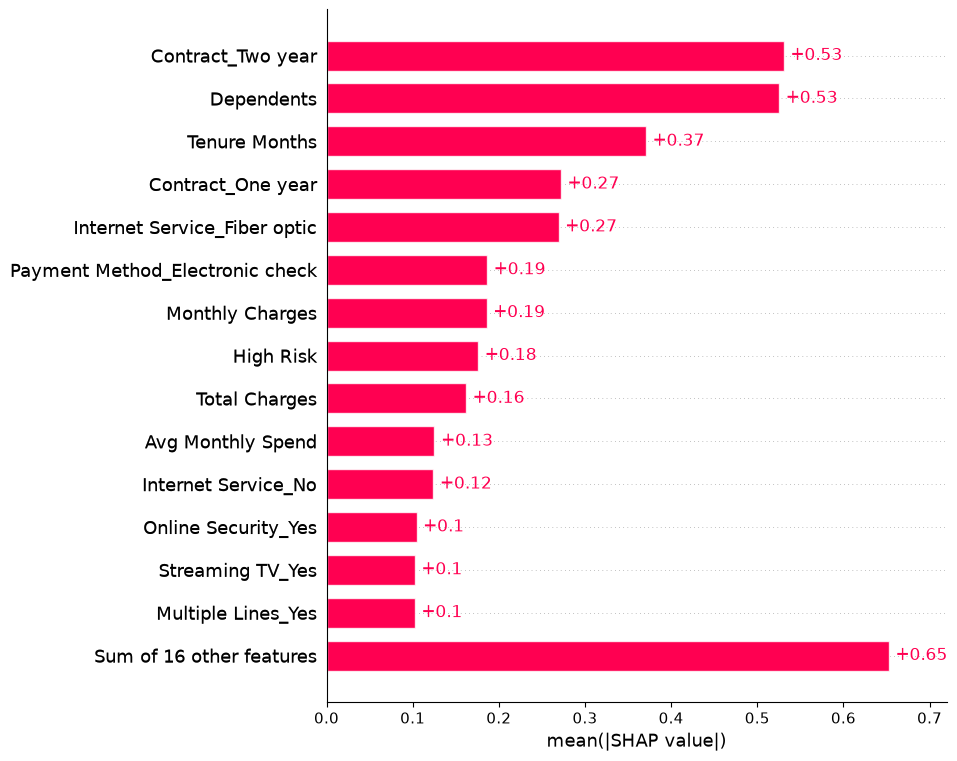

In [18]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Global feature importance
print('--- Global Feature Importance (mean |SHAP|) ---')
shap.plots.bar(shap_values, max_display=15)

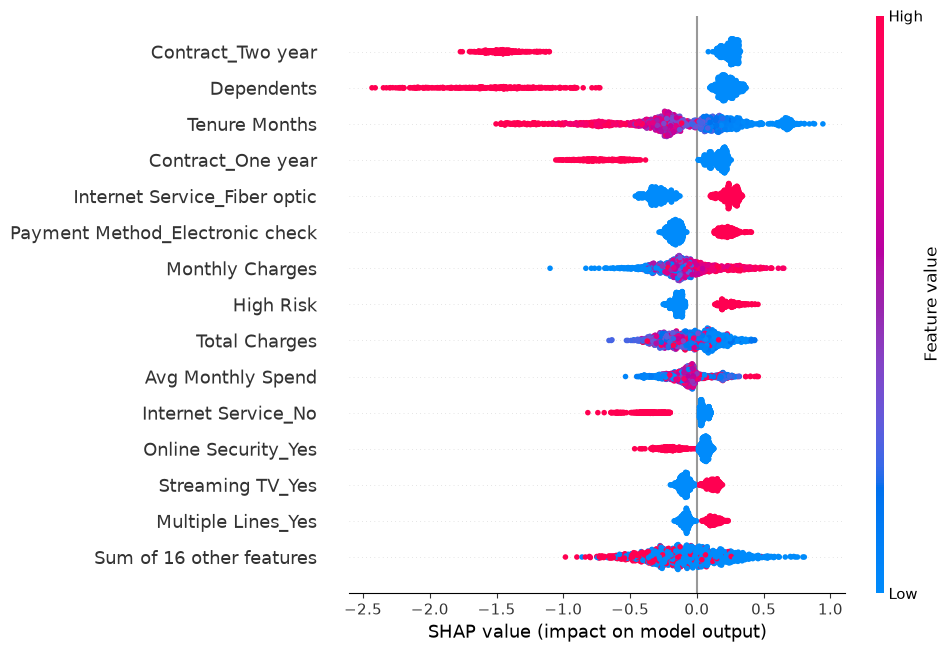

In [19]:
# Beeswarm — direction + magnitude of each feature across all test customers
shap.plots.beeswarm(shap_values, max_display=15)

Highest churn probability: 96.52%


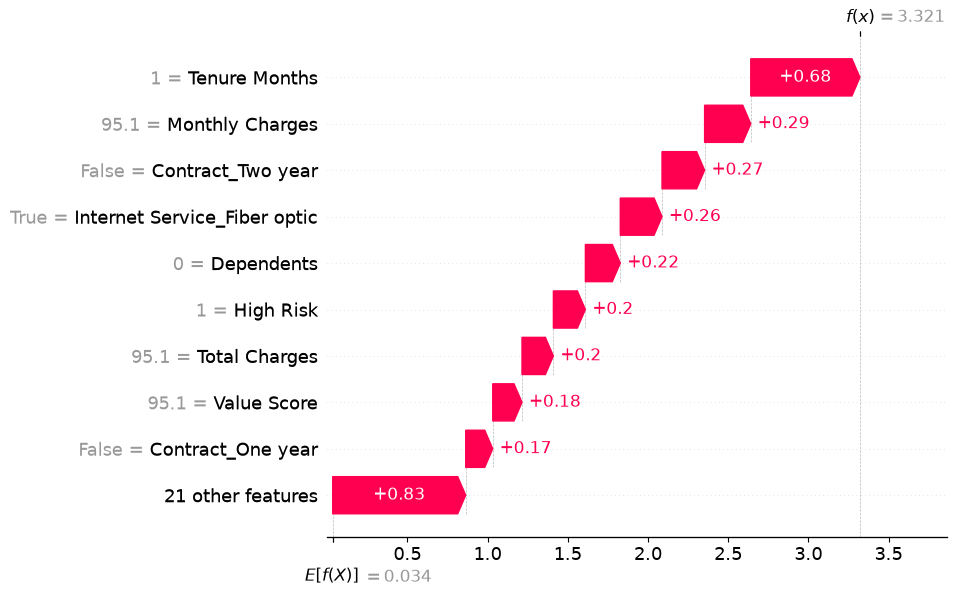

In [20]:
# Waterfall — individual prediction explanation for the highest-risk customer
highest_risk_idx = np.argmax(xgb_prob)
print(f'Highest churn probability: {xgb_prob[highest_risk_idx]:.2%}')
shap.plots.waterfall(shap_values[highest_risk_idx])

## 12. Summary

| Model | ROC-AUC |
|---|---|
| Logistic Regression | — |
| Random Forest | — |
| **XGBoost (tuned)** | **Best** |
| LightGBM | — |

**Key Findings:**
- Month-to-month contract customers and short-tenure customers are the highest churn risk.
- Higher Monthly Charges correlate strongly with churn.
- SHAP identifies the top drivers for any individual customer — actionable for retention teams.
- Custom threshold (0.3) improves churn recall at the cost of some precision — suitable when retention campaigns are cheap.

**Improvements in this version over original:**
1. `sklearn Pipeline` with `StandardScaler` — eliminates data leakage in LR scaling.
2. `class_weight='balanced'` added to Random Forest.
3. `StratifiedKFold` used explicitly in GridSearchCV.
4. EDA section added (churn by contract, tenure, charges).
5. SHAP Beeswarm plot added — shows feature direction, not just magnitude.
6. Waterfall shown for highest-risk customer — demonstrates individual explainability.
7. Side-by-side confusion matrix comparison at two thresholds with business rationale.
8. Classification Report added for complete precision/recall/F1 analysis.
9. `random_state` added to all models for reproducibility.
10. Markdown documentation throughout for clarity.